## Project Objective

**Primary dataset:** `early_warning_benchmark`

**Primary target:** `target_bloom_next_7d`

**Problem type:** Binary Classification

**Prediction question:**

Will this monitored coastal grid cell reach **≥ 100,000 Karenia brevis cells/L** within the next **7 days**?

## Feature Overview

The benchmark provides a predefined set of model features in `feature_columns.txt`.

The features can be grouped into the following categories:

- **Location features**
  - latitude and longitude
  - monitoring-grid coordinates

- **Current observation features**
  - current cell count
  - severity
  - sampling depth
  - salinity
  - water temperature
  - wind speed and direction

- **Temporal and seasonal features**
  - year
  - month
  - day of year
  - cyclical seasonal features

- **Missing-value indicators**
  - temperature missing
  - salinity missing
  - wind speed missing

- **Historical features**
  - previous observed cell count
  - days since the previous observation
  - bloom statistics over the previous 7, 30, and 90 days

- **Regional features**
  - recent bloom activity in nearby monitoring grids over 7, 30, and 90 days

The target and future-monitoring columns are intentionally excluded from the feature list to reduce the risk of data leakage.

## Dataset Download (Kaggle)

The dataset was downloaded into `data/raw` with the Kaggle CLI:

```bash
uv add kaggle

uv run kaggle datasets download   -d samoilovmikhail/florida-red-tide-early-warning-noaa-habsos   -p data/raw   --unzip
```

The main modelling files are the provided chronological train, validation, and test splits.

## 1. Load and Inspect the Training Data

In [6]:
from pathlib import Path

import pandas as pd

TRAIN_PATH = Path("../data/raw/early_warning_train.csv")

df_train = pd.read_csv(TRAIN_PATH)

print("Shape:", df_train.shape)
df_train.head()

Shape: (32304, 62)


,row_id,date,split,location_id,state,location_description,latitude,longitude,grid_latitude,grid_longitude,...,regional_30d_bloom_days,regional_90d_observation_days,regional_90d_max_cell_count,regional_90d_bloom_days,target_bloom_next_7d,target_severity_next_7d,target_max_cell_count_next_7d,target_log1p_max_cell_count_next_7d,target_observation_days_next_7d,days_to_next_observation
0,G010_+26.1_-081.8_20000103,2000-01-03,train,G010_+26.1_-081.8,FL,Naples Pier,26.13163,-81.80630,26.1,-81.8,...,0,0,NaN,0,0,2,10300.0,9.239996,1,7.0
1,G010_+26.2_-081.8_20000103,2000-01-03,train,G010_+26.2_-081.8,FL,Seagate,26.20730,-81.81690,26.2,-81.8,...,0,0,NaN,0,0,0,0.0,0.000000,1,7.0
2,G010_+26.3_-081.8_20000103,2000-01-03,train,G010_+26.3_-081.8,FL,Vanderbilt Beach,26.25375,-81.82377,26.3,-81.8,...,0,0,NaN,0,0,0,0.0,0.000000,2,1.0
3,G010_+26.3_-081.8_20000104,2000-01-04,train,G010_+26.3_-081.8,FL,Imperial River,26.34300,-81.83710,26.3,-81.8,...,0,1,8000.0,0,0,0,0.0,0.000000,1,6.0
4,G010_+27.1_-083.0_20000104,2000-01-04,train,G010_+27.1_-083.0,FL,New Pass; Sarasota; 25 mi; post-May 1998,27.13284,-82.98173,27.1,-83.0,...,0,1,8000.0,0,0,0,0.0,0.000000,1,6.0


In [7]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 32304 entries, 0 to 32303
Data columns (total 62 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   row_id                               32304 non-null  str    
 1   date                                 32304 non-null  str    
 2   split                                32304 non-null  str    
 3   location_id                          32304 non-null  str    
 4   state                                32304 non-null  str    
 5   location_description                 32300 non-null  str    
 6   latitude                             32304 non-null  float64
 7   longitude                            32304 non-null  float64
 8   grid_latitude                        32304 non-null  float64
 9   grid_longitude                       32304 non-null  float64
 10  cell_count                           32304 non-null  float64
 11  samples_today                        32

In [8]:
df_train.columns.tolist()

['row_id',
 'date',
 'split',
 'location_id',
 'state',
 'location_description',
 'latitude',
 'longitude',
 'grid_latitude',
 'grid_longitude',
 'cell_count',
 'samples_today',
 'sample_depth_m',
 'salinity',
 'water_temp_c',
 'wind_speed_mph',
 'wind_direction_deg',
 'current_severity',
 'current_is_bloom',
 'current_log1p_cell_count',
 'year',
 'month',
 'day_of_year',
 'season_sin',
 'season_cos',
 'water_temp_missing',
 'salinity_missing',
 'wind_speed_missing',
 'hist_previous_cell_count',
 'hist_previous_log1p_cell_count',
 'hist_days_since_previous_sample',
 'hist_7d_observation_days',
 'hist_7d_mean_cell_count',
 'hist_7d_max_cell_count',
 'hist_7d_bloom_days',
 'hist_7d_bloom_fraction',
 'hist_30d_observation_days',
 'hist_30d_mean_cell_count',
 'hist_30d_max_cell_count',
 'hist_30d_bloom_days',
 'hist_30d_bloom_fraction',
 'hist_90d_observation_days',
 'hist_90d_mean_cell_count',
 'hist_90d_max_cell_count',
 'hist_90d_bloom_days',
 'hist_90d_bloom_fraction',
 'regional_grid_

In [9]:
print("Shape:", df_train.shape)

Shape: (32304, 62)


## Initial Dataset Inspection

The training dataset contains:

- **32,304 rows**
- **62 columns**

The columns include three main groups:

- metadata and identifiers
- predefined model features
- future target and monitoring columns

The model features are defined separately in `feature_columns.txt`.

Future target columns such as `target_bloom_next_7d` must not be used as model inputs because this would cause data leakage.

Several environmental variables contain substantial amounts of missing data, especially wind-related measurements. These missing values will be investigated during the data-understanding phase.

## 2. Target Distribution


In [10]:
df_train["target_bloom_next_7d"].value_counts()

target_bloom_next_7d
0    30364
1     1940
Name: count, dtype: int64

In [11]:
df_train["target_bloom_next_7d"].value_counts(normalize=True) * 100

target_bloom_next_7d
0    93.994552
1     6.005448
Name: proportion, dtype: float64

In [12]:
df_train["target_bloom_next_7d"].value_counts()

target_bloom_next_7d
0    30364
1     1940
Name: count, dtype: int64

## Target Distribution

The binary target `target_bloom_next_7d` is  imbalanced:

- **Class 0:** 30,364 observations (~94%)
- **Class 1:** 1,940 observations (~6%)

This means that model evaluation should not rely on accuracy alone.

Metrics such as **precision, recall, F1-score, and the confusion matrix** will be more informative when evaluating the model's ability to detect future bloom events.

## 3. Data Quality and Coverage

In [13]:
missing_values = (
    df_train.isna()
    .sum()
    .sort_values(ascending=False)
)

missing_values.head(15)

wind_direction_deg          32140
wind_speed_mph              31975
water_temp_c                15451
salinity                    13352
hist_7d_bloom_fraction       6267
hist_7d_max_cell_count       6267
hist_7d_mean_cell_count      6267
hist_30d_max_cell_count      1400
hist_30d_bloom_fraction      1400
hist_30d_mean_cell_count     1400
hist_90d_max_cell_count       750
hist_90d_mean_cell_count      750
hist_90d_bloom_fraction       750
sample_depth_m                487
hist_previous_cell_count      109
dtype: int64

In [14]:
missing_percent = (
    df_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent.head(15)

wind_direction_deg          99.492323
wind_speed_mph              98.981550
water_temp_c                47.829990
salinity                    41.332343
hist_7d_bloom_fraction      19.400074
hist_7d_max_cell_count      19.400074
hist_7d_mean_cell_count     19.400074
hist_30d_max_cell_count      4.333829
hist_30d_bloom_fraction      4.333829
hist_30d_mean_cell_count     4.333829
hist_90d_max_cell_count      2.321694
hist_90d_mean_cell_count     2.321694
hist_90d_bloom_fraction      2.321694
sample_depth_m               1.507553
hist_previous_cell_count     0.337420
dtype: float64

## Missing Values

Several features contain substantial amounts of missing data.

The most affected variables are:

- `wind_direction_deg`: ~99.5% missing
- `wind_speed_mph`: ~99.0% missing
- `water_temp_c`: ~47.8% missing
- `salinity`: ~41.3% missing
- 7-day historical statistics: ~19.4% missing
- 30-day historical statistics: ~4.3% missing
- 90-day historical statistics: ~2.3% missing

The wind-related variables are almost entirely missing and may require special treatment later.

Missing values in historical features may be expected when insufficient prior observations are available.

At this stage, no features are removed or imputed. Missing-value handling will be decided during data preparation.

### check duplicate

In [15]:
df_train.duplicated().sum()

np.int64(0)

## Duplicate Check

No  duplicated rows were found in the training dataset.



### Training Period

In [16]:
df_train["date"].min(), df_train["date"].max()

('2000-01-03', '2018-12-31')

## Training Period

The training dataset covers date from:

- **2000-01-03**
- to **2018-12-31**



### Geographic Distribution

In [17]:
df_train["state"].value_counts()

state
FL    31550
TX      488
AL      187
MS       79
Name: count, dtype: int64

## Geographic Distribution

The training data is  concentrated in Florida:

- **Florida:** 31,550 observations
- **Texas:** 488 observations
- **Alabama:** 187 observations
- **Mississippi:** 79 observations

This indicates a strong geographic imbalance in the dataset.

The model will therefore learn primarily from Florida observations, and performance in the less represented states should be interpreted with caution.

### Temporal Distribution

In [18]:
df_train["year"].value_counts().sort_index()

year
2000     507
2001     450
2002     635
2003     916
2004     496
2005    1209
2006    1475
2007    1977
2008    1543
2009    1950
2010    1768
2011    2030
2012    1862
2013    2023
2014    2127
2015    1969
2016    2516
2017    3085
2018    3766
Name: count, dtype: int64

<Axes: title={'center': 'Training Observations by Year'}, xlabel='year'>

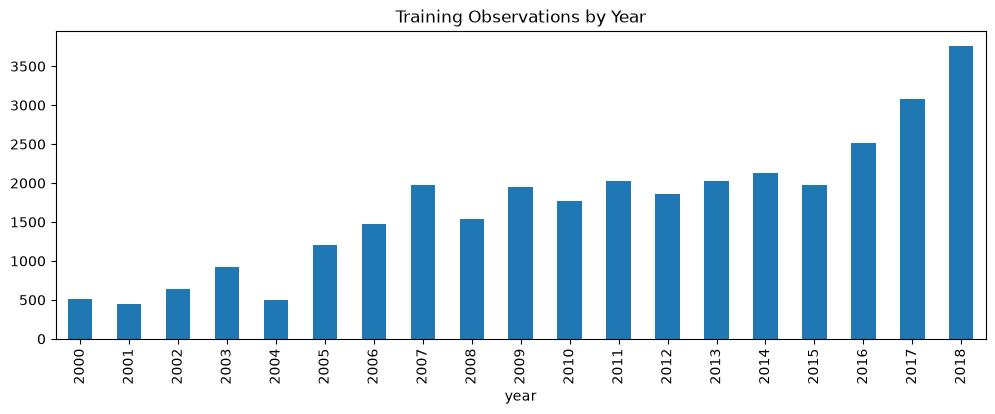

In [19]:
df_train["year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 4),
    title="Training Observations by Year"
)

## Temporal Distribution

The number of training observations varies  across the years 2000–2018.

Earlier years generally contain fewer observations, while the number of available samples increases substantially in later years.

For example:

- **2000:** 507 observations
- **2010:** 1,768 observations
- **2016:** 2,516 observations
- **2017:** 3,085 observations
- **2018:** 3,766 observations

This indicates that monitoring coverage or sampling frequency has changed over time.

### Bloom Rate Over Time

In [20]:
bloom_rate_by_year = (
    df_train.groupby("year")["target_bloom_next_7d"]
    .mean()
    .mul(100)
)

bloom_rate_by_year

year
2000     6.114398
2001    20.222222
2002     8.661417
2003    11.353712
2004     4.435484
2005    14.888337
2006    11.796610
2007     4.653515
2008     0.388853
2009     2.717949
2010     0.169683
2011     5.812808
2012     6.552095
2013     4.300544
2014     0.987306
2015     5.129507
2016     5.802862
2017     3.014587
2018    11.710037
Name: target_bloom_next_7d, dtype: float64

<Axes: title={'center': 'Bloom Rate by Year'}, xlabel='year'>

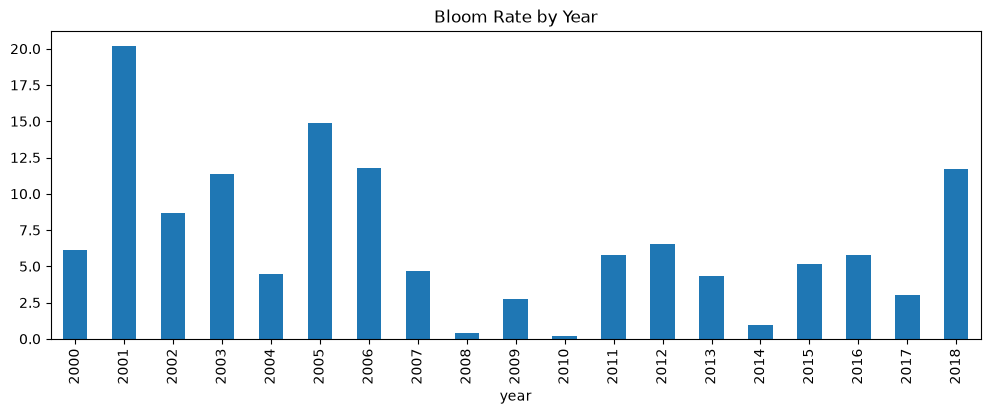

In [21]:
bloom_rate_by_year.plot(
    kind="bar",
    figsize=(12, 4),
    title="Bloom Rate by Year"
)

## Bloom Rate Over Time

The proportion of positive bloom-onset examples varies considerably across the training period.

Some years show relatively high bloom rates, while others contain very few positive cases.

Examples:

- **2001:** ~20.2%
- **2005:** ~14.9%
- **2010:** ~0.2%
- **2014:** ~1.0%
- **2018:** ~11.7%

This indicates that the target distribution changes over time rather than remaining constant.

The chronological train/validation/test split is therefore especially important, because future periods may differ meaningfully from earlier training years.

### Current Severity and Bloom Status

In [22]:
df_train["current_severity"].value_counts().sort_index()

current_severity
0    25226
1     4410
2     2668
Name: count, dtype: int64

## Current Severity Distribution

The current observations contain only severity levels below the bloom threshold:

- **Severity 0 — Not observed:** 25,226 observations
- **Severity 1 — Very low:** 4,410 observations
- **Severity 2 — Low:** 2,668 observations

No observations start at severity levels 3 or 4.

This confirms that the benchmark is designed to predict **future bloom onset or escalation**, rather than detect blooms that are already present.

In [23]:
df_train["current_is_bloom"].value_counts()

current_is_bloom
0    32304
Name: count, dtype: int64

## Current Bloom Status

The feature `current_is_bloom` is equal to `0` for all training observations.

This confirms that every benchmark example starts below the bloom threshold.

The prediction task is therefore focused on **future bloom onset or escalation within the next 7 days**.

Since `current_is_bloom` is constant across the training set, it does not provide useful predictive information.

### Current Cell Count Distribution

In [24]:
df_train["cell_count"].describe()

count    32304.000000
mean      3572.407132
std      12909.407910
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99763.000000
Name: cell_count, dtype: float64

In [25]:
(df_train["cell_count"] == 0).mean() * 100


np.float64(78.08940069341259)

## Current Cell Count Distribution

The current `cell_count` feature is strongly right-skewed.

- **Minimum:** 0 cells/L
- **Median:** 0 cells/L
- **75th percentile:** 0 cells/L
- **Mean:** ~3,572 cells/L
- **Maximum:** 99,763 cells/L
- **Zero cell count:** ~78.1% of all training observations

Most observations therefore contain no currently detected *Karenia brevis* cells, while a relatively small number of higher measurements increase the mean substantially.

The maximum current concentration remains below the bloom threshold of **100,000 cells/L**, which is consistent with the benchmark design.

In [26]:
df_train["current_log1p_cell_count"].describe()

count    32304.000000
mean         1.845072
std          3.582231
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         11.510563
Name: current_log1p_cell_count, dtype: float64

## Log-Transformed Cell Count

The benchmark also provides `current_log1p_cell_count`, a log-transformed version of the current cell count.

The transformation compresses large concentration values and reduces the extreme scale difference between low and high measurements.

Because approximately 78% of the original cell counts are zero, the lower quartiles of the transformed feature also remain at zero.

The transformation is defined as:

`log(1 + cell_count)`

This allows zero values to be transformed safely while reducing the influence of very large cell-count values.

## Data Cleaning and Feature Preparation

In [27]:
FEATURE_PATH = Path("../data/raw/feature_columns.txt")

feature_columns = FEATURE_PATH.read_text().splitlines()

len(feature_columns)

49

In [28]:
feature_columns[:10]

['latitude',
 'longitude',
 'grid_latitude',
 'grid_longitude',
 'cell_count',
 'samples_today',
 'sample_depth_m',
 'salinity',
 'water_temp_c',
 'wind_speed_mph']

In [29]:
X_train = df_train[feature_columns]
y_train = df_train["target_bloom_next_7d"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (32304, 49)
y_train shape: (32304,)


In [30]:
unique_counts = X_train.nunique().sort_values()

unique_counts.head(10)

salinity_missing                 2
water_temp_missing               2
wind_speed_missing               2
current_severity                 3
hist_7d_observation_days         8
regional_7d_observation_days     8
hist_7d_bloom_days               8
regional_7d_bloom_days           8
month                           12
year                            19
dtype: int64

## Feature Cardinality Check

No constant features were found among the 49 predefined model features.

Features with very low cardinality are expected and meaningful:

- missing-value indicators are binary
- `current_severity` has three levels
- month contains 12 categories
- year contains 19 values

No feature needs to be removed solely because it has only one unique value.

In [31]:
feature_missing = (
    X_train.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

feature_missing.head(15)

wind_direction_deg          99.492323
wind_speed_mph              98.981550
water_temp_c                47.829990
salinity                    41.332343
hist_7d_bloom_fraction      19.400074
hist_7d_mean_cell_count     19.400074
hist_7d_max_cell_count      19.400074
hist_30d_mean_cell_count     4.333829
hist_30d_bloom_fraction      4.333829
hist_30d_max_cell_count      4.333829
hist_90d_bloom_fraction      2.321694
hist_90d_max_cell_count      2.321694
hist_90d_mean_cell_count     2.321694
sample_depth_m               1.507553
hist_previous_cell_count     0.337420
dtype: float64

## Missing Value Strategy

The predefined feature set contains several variables with missing values.

The two wind-related variables are almost completely missing:

- `wind_direction_deg`: ~99.5%
- `wind_speed_mph`: ~99.0%

For the initial baseline model, these two features will be excluded because there is too little observed data to support meaningful imputation.

Other variables with missing values, such as `water_temp_c`, `salinity`, and historical statistics, will be retained for now.

The benchmark already provides missing-value indicators for several environmental variables, which allows missingness itself to remain available as model information.

In [32]:
features_to_drop = [
    "wind_speed_mph",
    "wind_direction_deg",
]

clean_feature_columns = [
    col for col in feature_columns
    if col not in features_to_drop
]

len(clean_feature_columns)

47

In [33]:
X_train_clean = df_train[clean_feature_columns]

X_train_clean.shape

(32304, 47)

### Remaining Missing Values After Dropping Wind Measurements

In [34]:
X_train_clean.isna().sum().sum()

np.int64(54978)

In [35]:
X_train_clean.isna().sum().sort_values(ascending=False).head(15)

water_temp_c                       15451
salinity                           13352
hist_7d_mean_cell_count             6267
hist_7d_max_cell_count              6267
hist_7d_bloom_fraction              6267
hist_30d_max_cell_count             1400
hist_30d_bloom_fraction             1400
hist_30d_mean_cell_count            1400
hist_90d_max_cell_count              750
hist_90d_bloom_fraction              750
hist_90d_mean_cell_count             750
sample_depth_m                       487
hist_days_since_previous_sample      109
hist_previous_log1p_cell_count       109
hist_previous_cell_count             109
dtype: int64

In [36]:
X_train_clean.dtypes.value_counts()

float64    26
int64      21
Name: count, dtype: int64

### Median Imputation

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [38]:
X_train_imputed = imputer.fit_transform(X_train_clean)

In [39]:
X_train_imputed.shape

(32304, 47)

In [40]:
import numpy as np

np.isnan(X_train_imputed).sum()

np.int64(0)

In [92]:
import joblib
from pathlib import Path

Path("artifacts").mkdir(exist_ok=True)

joblib.dump(imputer, "artifacts/imputer.joblib")

['artifacts/imputer.joblib']

## Missing Value Imputation

The remaining missing values were handled using median imputation.

After imputation:

- feature shape remains unchanged
- no missing values remain in the training feature matrix

In [41]:
type(X_train_imputed)

numpy.ndarray

In [42]:
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=clean_feature_columns,
    index=X_train_clean.index,
)

In [43]:
type(X_train_imputed)

pandas.DataFrame

In [44]:
X_train_imputed.head()


,latitude,longitude,grid_latitude,grid_longitude,cell_count,samples_today,sample_depth_m,salinity,water_temp_c,current_severity,...,regional_grid_days,regional_7d_observation_days,regional_7d_max_cell_count,regional_7d_bloom_days,regional_30d_observation_days,regional_30d_max_cell_count,regional_30d_bloom_days,regional_90d_observation_days,regional_90d_max_cell_count,regional_90d_bloom_days
0,26.13163,-81.80630,26.1,-81.8,8000.0,1.0,0.5,35.0000,25.800,1.0,...,3.0,0.0,58000.0,0.0,0.0,473000.0,0.0,0.0,2560000.0,0.0
1,26.20730,-81.81690,26.2,-81.8,333.0,1.0,0.5,35.0000,25.800,1.0,...,3.0,0.0,58000.0,0.0,0.0,473000.0,0.0,0.0,2560000.0,0.0
2,26.25375,-81.82377,26.3,-81.8,0.0,1.0,0.5,34.0000,25.800,0.0,...,3.0,0.0,58000.0,0.0,0.0,473000.0,0.0,0.0,2560000.0,0.0
3,26.34300,-81.83710,26.3,-81.8,0.0,2.0,0.5,18.0000,25.800,0.0,...,20.0,1.0,8000.0,0.0,1.0,8000.0,0.0,1.0,8000.0,0.0
4,27.13284,-82.98173,27.1,-83.0,0.0,4.0,10.4,36.2455,20.525,0.0,...,20.0,1.0,8000.0,0.0,1.0,8000.0,0.0,1.0,8000.0,0.0


## Imputed Training Features

The training feature matrix was transformed using median imputation.

After the transformation:

- the dataset still contains **32,304 rows**
- **47 model features** remain
- all missing values have been handled
- the transformed NumPy array was converted back into a Pandas DataFrame
- the original feature names and row index were preserved

This keeps the dataset easier to inspect and review before model training.

## 5. Baseline Model Training

A `RandomForestClassifier` is used as the first baseline.

- `random_state=42` makes the result reproducible.
- `class_weight="balanced"` compensates for the strongly imbalanced target.
- No feature scaling is required for the Random Forest baseline.

In [45]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
)

baseline_model.fit(X_train_imputed, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [48]:
baseline_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

## 6. Validation Set Preparation and Baseline Evaluation

In [46]:
VALIDATION_PATH = Path("../data/raw/early_warning_validation.csv")

df_validation = pd.read_csv(VALIDATION_PATH)

print("Shape:", df_validation.shape)

Shape: (8668, 62)


In [47]:
X_validation = df_validation[clean_feature_columns]
y_validation = df_validation["target_bloom_next_7d"]

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

X_validation shape: (8668, 47)
y_validation shape: (8668,)


In [48]:
X_validation_imputed = imputer.transform(X_validation)

In [49]:
X_validation_imputed = pd.DataFrame(
    X_validation_imputed,
    columns=clean_feature_columns,
    index=X_validation.index,
)

In [50]:
X_validation_imputed.shape

(8668, 47)

In [51]:
X_validation_imputed.isna().sum().sum()

np.int64(0)

In [52]:
y_validation_pred = baseline_model.predict(X_validation_imputed)

In [53]:
y_validation_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [54]:
pd.Series(y_validation_pred).value_counts()

0    8341
1     327
Name: count, dtype: int64

### Confusion Matrix

In [55]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_validation,
    y_validation_pred
)

array([[8101,  223],
       [ 240,  104]])

## Baseline Confusion Matrix

The baseline Random Forest produced:

- **True Negatives:** 8,101
- **False Positives:** 223
- **False Negatives:** 240
- **True Positives:** 104

The model identifies some future bloom events, but it still misses a substantial number of positive cases.

For an early-warning system, the false negatives are particularly important because they represent bloom events that were not detected in advance.

### Recall

In [56]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_validation,
    y_validation_pred
)

recall

0.3023255813953488

## Recall

The baseline model achieves a recall of approximately **30.2%**.

This means that the model correctly identifies about **3 out of 10** actual future bloom events.

For an early-warning system, this is an important limitation because a large number of true bloom events are still missed.

### Precision

In [57]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_validation,
    y_validation_pred
)

precision

0.3180428134556575

### F1-Score

In [58]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_validation,
    y_validation_pred
)

f1

0.30998509687034276

## F1-Score

The baseline model achieves an F1-score of approximately **31.0%**.

This reflects the balance between:

- **Precision:** ~31.8%
- **Recall:** ~30.2%

The relatively low F1-score confirms that the baseline model still has limited performance on the positive bloom class.

### Accuracy

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

accuracy

0.9465851407475773

## Accuracy

The baseline model achieves an accuracy of approximately **94.7%**.

However, the dataset is strongly imbalanced and most observations belong to class `0`.

Therefore, the high accuracy is misleading when viewed alone.

The much lower recall, precision, and F1-score show that the model still performs poorly on the minority bloom class.

### Validation Target Distribution

In [60]:
y_validation.value_counts(normalize=True) * 100

target_bloom_next_7d
0    96.03138
1     3.96862
Name: proportion, dtype: float64

 ## Validation Target Distribution

The validation set is also strongly imbalanced:

- **Class 0:** ~96.0%
- **Class 1:** ~4.0%

The positive class is even less frequent than in the training set.

This reinforces why metrics such as **recall, precision, F1-score, and the confusion matrix** are more informative than accuracy alone.

### Feature Importance

In [61]:
feature_importance = pd.Series(
    baseline_model.feature_importances_,
    index=clean_feature_columns,
).sort_values(ascending=False)

feature_importance.head(10)

cell_count                        0.086399
current_log1p_cell_count          0.068253
current_severity                  0.067295
hist_30d_mean_cell_count          0.060511
regional_7d_max_cell_count        0.050612
hist_30d_max_cell_count           0.042366
regional_30d_max_cell_count       0.038520
hist_previous_log1p_cell_count    0.036964
hist_90d_mean_cell_count          0.031233
hist_previous_cell_count          0.029934
dtype: float64

## Feature Importance

The baseline Random Forest relies mainly on:

- current bloom-related measurements
- recent local historical activity
- recent regional bloom activity

The most important features include:

- `cell_count`
- `current_log1p_cell_count`
- `current_severity`
- `hist_30d_mean_cell_count`
- `regional_7d_max_cell_count`

This suggests that the model uses both the current local state and recent historical/regional bloom patterns to estimate future bloom risk.

In [62]:
y_validation_proba = baseline_model.predict_proba(
    X_validation_imputed
)[:, 1]

In [63]:
y_validation_proba[:20]

array([0.06, 0.06, 0.06, 0.12, 0.05, 0.11, 0.15, 0.09, 0.16, 0.1 , 0.31,
       0.3 , 0.07, 0.23, 0.23, 0.24, 0.37, 0.43, 0.16, 0.18])

In [64]:
threshold = 0.30

y_validation_pred_030 = (
    y_validation_proba >= threshold
).astype(int)

In [65]:
confusion_matrix(
    y_validation,
    y_validation_pred_030
)

array([[7668,  656],
       [ 116,  228]])

## Decision Threshold Adjustment

Lowering the decision threshold from **0.5** to **0.3** substantially changes the model behavior.

At threshold 0.5:

- True Positives: 104
- False Negatives: 240
- False Positives: 223

At threshold 0.3:

- True Positives: 228
- False Negatives: 116
- False Positives: 656

The lower threshold greatly improves recall by detecting more true bloom events, but it also increases the number of false alarms.

This illustrates the trade-off between **recall** and **precision** in an early-warning system.

In [66]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

precision_030 = precision_score(y_validation, y_validation_pred_030)
recall_030 = recall_score(y_validation, y_validation_pred_030)
f1_030 = f1_score(y_validation, y_validation_pred_030)
accuracy_030 = accuracy_score(y_validation, y_validation_pred_030)

print("Threshold 0.3")
print("Precision:", precision_030)
print("Recall:", recall_030)
print("F1:", f1_030)
print("Accuracy:", accuracy_030)

Threshold 0.3
Precision: 0.2579185520361991
Recall: 0.6627906976744186
F1: 0.3713355048859935
Accuracy: 0.9109367789570835


## Threshold Comparison

Lowering the decision threshold from **0.5** to **0.3** changes the model behavior substantially.

| Metric | Threshold 0.5 | Threshold 0.3 |
|---|---:|---:|
| Precision | 31.8% | 25.8% |
| Recall | 30.2% | 66.3% |
| F1-score | 31.0% | 37.1% |
| Accuracy | 94.7% | 91.1% |

The lower threshold detects substantially more true bloom events.

However, this improvement in recall comes at the cost of more false-positive warnings and lower precision.

For an early-warning system, this trade-off may be acceptable when missing a real bloom is considered more costly than issuing an additional warning.

In [68]:
threshold = 0.40

y_validation_pred_040 = (
    y_validation_proba >= threshold
).astype(int)

In [69]:
precision_040 = precision_score(
    y_validation,
    y_validation_pred_040
)

recall_040 = recall_score(
    y_validation,
    y_validation_pred_040
)

f1_040 = f1_score(
    y_validation,
    y_validation_pred_040
)

accuracy_040 = accuracy_score(
    y_validation,
    y_validation_pred_040
)

print("Threshold 0.4")
print("Precision:", precision_040)
print("Recall:", recall_040)
print("F1:", f1_040)
print("Accuracy:", accuracy_040)

Threshold 0.4
Precision: 0.29895104895104896
Recall: 0.49709302325581395
F1: 0.37336244541484714
Accuracy: 0.9337794185509921


In [70]:
confusion_matrix(
    y_validation,
    y_validation_pred_040
)

array([[7923,  401],
       [ 173,  171]])

## Decision Threshold Comparison

Three decision thresholds were evaluated on the validation set:

| Metric | Threshold 0.3 | Threshold 0.4 | Threshold 0.5 |
|---|---:|---:|---:|
| Precision | 25.8% | 29.9% | 31.8% |
| Recall | 66.3% | 49.7% | 30.2% |
| F1-score | 37.1% | 37.3% | 31.0% |
| Accuracy | 91.1% | 93.4% | 94.7% |

A threshold of **0.4** provides the most balanced performance among the tested values and achieves the highest F1-score.

A lower threshold of **0.3** provides substantially higher recall and may be preferable when missing a real bloom event is considered more costly than issuing additional false alarms.

In [71]:
TEST_PATH = Path("../data/raw/early_warning_test.csv")

df_test = pd.read_csv(TEST_PATH)

print("Shape:", df_test.shape)

Shape: (4659, 62)


In [72]:
X_test = df_test[clean_feature_columns]
y_test = df_test["target_bloom_next_7d"]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (4659, 47)
y_test shape: (4659,)


In [73]:
X_test_imputed = imputer.transform(X_test)

In [74]:
X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=clean_feature_columns,
    index=X_test.index,
)

In [75]:
print("Shape:", X_test_imputed.shape)
print("Missing values:", X_test_imputed.isna().sum().sum())

Shape: (4659, 47)
Missing values: 0


In [76]:
y_test_proba = baseline_model.predict_proba(X_test_imputed)[:, 1]

y_test_pred = (y_test_proba >= 0.4).astype(int)

In [77]:
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))

confusion_matrix(y_test, y_test_pred)

Precision: 0.3522012578616352
Recall: 0.4
F1: 0.3745819397993311
Accuracy: 0.9598626314659798


array([[4416,  103],
       [  84,   56]])

## Final Test Evaluation

The final model was evaluated on the held-out test set using a decision threshold of **0.4**.

Final test metrics:

- **Precision:** 35.2%
- **Recall:** 40.0%
- **F1-score:** 37.5%
- **Accuracy:** 96.0%

The high accuracy is strongly influenced by the imbalanced class distribution.

The more informative metrics show that the model detects a meaningful share of future bloom events, but still misses many positive cases.

Overall, the baseline model provides a reasonable starting point, but further improvement would be required for a production-grade early-warning system.    

## MLFlow 

In [78]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

mlflow.set_experiment("florida-red-tide")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790757787332, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790757787332, lifecycle_stage='active', name='florida-red-tide', tags={}, trace_location=None, workspace='default'>

## Just a Run Test

In [79]:
with mlflow.start_run():

    mlflow.log_param("model", "test-model")
    mlflow.log_param("threshold", 0.4)

    mlflow.log_metric("precision", 0.35)
    mlflow.log_metric("recall", 0.40)
    mlflow.log_metric("f1", 0.37)

🏃 View run fun-foal-20 at: http://127.0.0.1:5000/#/experiments/1/runs/d33660c12fae497f89f0e6db71cb340b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## First Real flow run

In [80]:
import mlflow

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

with mlflow.start_run(run_name="baseline-random-forest"):

    baseline_model = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
    )

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")

    baseline_model.fit(X_train_imputed, y_train)

    y_pred = baseline_model.predict(X_test_imputed)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

Accuracy: 0.9678042498390212
Precision: 0.4305555555555556
Recall: 0.22142857142857142
F1: 0.29245283018867924
🏃 View run baseline-random-forest at: http://127.0.0.1:5000/#/experiments/1/runs/753160a89f1642f88da643edba328c38
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## Second MLflow run 

In [81]:
threshold = 0.4

with mlflow.start_run(run_name="baseline-random-forest-threshold-04"):

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("threshold", threshold)

    y_prob = baseline_model.predict_proba(X_test_imputed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    print("Threshold:", threshold)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

Threshold: 0.4
Accuracy: 0.9598626314659798
Precision: 0.3522012578616352
Recall: 0.4
F1: 0.3745819397993311
🏃 View run baseline-random-forest-threshold-04 at: http://127.0.0.1:5000/#/experiments/1/runs/ecc1aad840b644cc8ea6b91b562f9e42
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [82]:
threshold = 0.3

with mlflow.start_run(run_name="baseline-random-forest-threshold-03"):

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("threshold", threshold)

    y_prob = baseline_model.predict_proba(X_test_imputed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    print("Threshold:", threshold)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

Threshold: 0.3
Accuracy: 0.943979394719897
Precision: 0.2862190812720848
Recall: 0.5785714285714286
F1: 0.3829787234042553
🏃 View run baseline-random-forest-threshold-03 at: http://127.0.0.1:5000/#/experiments/1/runs/3b26ccc861074063912c63963b388516
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [85]:
import mlflow
import mlflow.sklearn

threshold = 0.3

with mlflow.start_run(run_name="baseline-random-forest-threshold-03"):

    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("threshold", threshold)

    y_prob = baseline_model.predict_proba(X_test_imputed)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    mlflow.log_metric("accuracy", accuracy_score(y_test, y_pred))
    mlflow.log_metric("precision", precision_score(y_test, y_pred))
    mlflow.log_metric("recall", recall_score(y_test, y_pred))
    mlflow.log_metric("f1", f1_score(y_test, y_pred))

    mlflow.sklearn.log_model(
        sk_model=baseline_model,
        name="model",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ],
    )

2026/09/30 12:27:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run baseline-random-forest-threshold-03 at: http://127.0.0.1:5000/#/experiments/1/runs/b923e45376a347f89b8c417d3f7ac1b8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


## After registration, load model and test prediction

In [86]:
import mlflow.sklearn

model_uri = "models:/florida-red-tide-classifier/1"

loaded_model = mlflow.sklearn.load_model(model_uri)

In [87]:
y_prob = loaded_model.predict_proba(X_test_imputed)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print(y_pred[:10])
print(y_prob[:10])

[0 0 0 0 0 0 0 0 0 0]
[0.08 0.03 0.02 0.04 0.05 0.04 0.03 0.18 0.11 0.12]


In [88]:
print(X_train_imputed.columns.tolist())

['latitude', 'longitude', 'grid_latitude', 'grid_longitude', 'cell_count', 'samples_today', 'sample_depth_m', 'salinity', 'water_temp_c', 'current_severity', 'current_log1p_cell_count', 'year', 'month', 'day_of_year', 'season_sin', 'season_cos', 'water_temp_missing', 'salinity_missing', 'wind_speed_missing', 'hist_previous_cell_count', 'hist_previous_log1p_cell_count', 'hist_days_since_previous_sample', 'hist_7d_observation_days', 'hist_7d_mean_cell_count', 'hist_7d_max_cell_count', 'hist_7d_bloom_days', 'hist_7d_bloom_fraction', 'hist_30d_observation_days', 'hist_30d_mean_cell_count', 'hist_30d_max_cell_count', 'hist_30d_bloom_days', 'hist_30d_bloom_fraction', 'hist_90d_observation_days', 'hist_90d_mean_cell_count', 'hist_90d_max_cell_count', 'hist_90d_bloom_days', 'hist_90d_bloom_fraction', 'regional_grid_days', 'regional_7d_observation_days', 'regional_7d_max_cell_count', 'regional_7d_bloom_days', 'regional_30d_observation_days', 'regional_30d_max_cell_count', 'regional_30d_bloom_da

In [89]:
type(X_test)

pandas.DataFrame

In [93]:
sample = X_test.iloc[0]
print(sample.to_json(indent=2))

{
  "latitude":30.1762,
  "longitude":-85.8119,
  "grid_latitude":30.2,
  "grid_longitude":-85.8,
  "cell_count":0.0,
  "samples_today":1.0,
  "sample_depth_m":0.5,
  "salinity":null,
  "water_temp_c":null,
  "current_severity":0.0,
  "current_log1p_cell_count":0.0,
  "year":2022.0,
  "month":1.0,
  "day_of_year":2.0,
  "season_sin":0.03439806,
  "season_cos":0.9994082,
  "water_temp_missing":1.0,
  "salinity_missing":1.0,
  "wind_speed_missing":1.0,
  "hist_previous_cell_count":1667.0,
  "hist_previous_log1p_cell_count":7.4193805829,
  "hist_days_since_previous_sample":56.0,
  "hist_7d_observation_days":0.0,
  "hist_7d_mean_cell_count":null,
  "hist_7d_max_cell_count":null,
  "hist_7d_bloom_days":0.0,
  "hist_7d_bloom_fraction":null,
  "hist_30d_observation_days":0.0,
  "hist_30d_mean_cell_count":null,
  "hist_30d_max_cell_count":null,
  "hist_30d_bloom_days":0.0,
  "hist_30d_bloom_fraction":null,
  "hist_90d_observation_days":7.0,
  "hist_90d_mean_cell_count":28182.0,
  "hist_90d_max

In [91]:
type(baseline_model)

sklearn.ensemble._forest.RandomForestClassifier